In [1]:
#Loading the data 

In [2]:
import pandas as pd 
import numpy as np

In [3]:
GND = pd.read_csv('C:\\Users\\ritik\\OneDrive\\Documents\\GitHub\\Multi-Model-Bias-Detection-and-Debiasing-the-News\\Good_News_Dataset\\combined_dataset.csv',delimiter=',')

In [4]:
GND.size

2427576

In [5]:
GND.shape[0]

404596

In [6]:
GND.isna().sum()

image_path         0
caption        34813
article            0
headline           2
article_id         0
image_index        0
dtype: int64

In [7]:
gnd_nona = GND.dropna()

In [8]:
gnd_nona.isna().sum()

image_path     0
caption        0
article        0
headline       0
article_id     0
image_index    0
dtype: int64

Lower Casing the whole dataset 

In [9]:
gnd_nona = gnd_nona.applymap(lambda x: x.lower() if isinstance(x, str) else x)


C:\Users\ritik\AppData\Local\Temp\ipykernel_25624\1671697315.py:1: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  gnd_nona = gnd_nona.applymap(lambda x: x.lower() if isinstance(x, str) else x)


In [10]:
gnd_nona['caption'] = gnd_nona['caption'].replace(to_replace=r'[^\w\s]', value='', regex=True)
gnd_nona['article'] = gnd_nona['article'].replace(to_replace=r'[^\w\s]', value='', regex=True)
gnd_nona['headline'] = gnd_nona['headline'].replace(to_replace=r'[^\w\s]', value='', regex=True)


In [11]:
!pip install transformers

In [12]:
gnd_nona.shape[0]

369781

The dataset is quite big and I would need more computing power to just tokenize it . So it is better I take random sample of data from it 

In [13]:
gnd_sampled = gnd_nona.sample(n=100000,random_state=42)

In [14]:
gnd_sampled.shape[0]

100000

In [15]:
gnd_sampled.head()

,image_path,caption,article,headline,article_id,image_index
35099,c:\users\ritik\goodnews\images\5650a72838f0d82...,iraqi security forces training on mosuls outsk...,the attacks in paris last week were a deadly d...,pentagon expands inquiry into intelligence on ...,5650a72838f0d82713feb4ea,1
309071,c:\users\ritik\goodnews\images\55b18b2d38f0d82...,deputy secretary of defense bob work what happ...,washington the pentagon said on thursday that...,procedures faulted in army lab8217s shipment o...,55b18b2d38f0d820636df774,0
45261,c:\users\ritik\goodnews\images\515dadbfcf28d02...,\nafter scrambling on this play brady threw an...,guard logan mankins said ive lost a lot of gam...,drop by welker bradys most reliable receiver h...,515dadbfcf28d0219d002c71,1
44344,c:\users\ritik\goodnews\images\57f7c5ff95d0e02...,work by mark rothko at the portland art museum...,under the heading of localboymakesgood the pai...,mark rothko son of oregon to be honored with m...,57f7c5ff95d0e021d798aafe,1
70416,c:\users\ritik\goodnews\images\5245e3e638f0d81...,\npeople wait in line at the anne frank house\n\n,the train station used to be at the other end ...,the ghosts of amsterdam,5245e3e638f0d8198973d908,5


In [16]:
gnd_sampled.columns

Index(['image_path', 'caption', 'article', 'headline', 'article_id',
       'image_index'],
      dtype='object')

In [17]:
import os
from PIL import Image
def remove_corrupted_image(path,dataset):
    path_=path.replace('\\','/')
    try:
        with Image.open(path_) as img:
            img.verify() 
        return False 
    except (IOError, SyntaxError) as e:
        print(f"Removing corrupted image: {path_} - {e}")
        dataset = dataset.drop(dataset[dataset['image_path'] == path].index,inplace=True)
        return True

In [18]:
gnd_sampled['image_path'].apply(lambda x : remove_corrupted_image(x,gnd_sampled))

Removing corrupted image: c:/users/ritik/goodnews/images/5445644438f0d832c813eb52_0.jpg - cannot identify image file 'C:\\Users\\ritik\\GoodNews\\images\\5445644438f0d832c813eb52_0.jpg'
Removing corrupted image: c:/users/ritik/goodnews/images/5111a5e200315214fbb89668_0.jpg - cannot identify image file 'C:\\Users\\ritik\\GoodNews\\images\\5111a5e200315214fbb89668_0.jpg'
Removing corrupted image: c:/users/ritik/goodnews/images/52b89a3338f0d86bcb2a659a_1.jpg - cannot identify image file 'C:\\Users\\ritik\\GoodNews\\images\\52b89a3338f0d86bcb2a659a_1.jpg'
Removing corrupted image: c:/users/ritik/goodnews/images/56f7bd4938f0d857ea327a1b_0.jpg - cannot identify image file 'C:\\Users\\ritik\\GoodNews\\images\\56f7bd4938f0d857ea327a1b_0.jpg'
Removing corrupted image: c:/users/ritik/goodnews/images/57bb279195d0e021d7981fbb_0.jpg - cannot identify image file 'C:\\Users\\ritik\\GoodNews\\images\\57bb279195d0e021d7981fbb_0.jpg'
Removing corrupted image: c:/users/ritik/goodnews/images/515dafc1cf28d

35099     False
309071    False
45261     False
44344     False
70416     False
          ...  
340840    False
143269    False
123581    False
261036    False
323060    False
Name: image_path, Length: 100000, dtype: bool

In [19]:
gnd_sampled.shape[0]

99386

In [20]:
gnd_sampled = gnd_sampled.reset_index(drop=True)


In [21]:
gnd_sampled.head()

,image_path,caption,article,headline,article_id,image_index
0,c:\users\ritik\goodnews\images\5650a72838f0d82...,iraqi security forces training on mosuls outsk...,the attacks in paris last week were a deadly d...,pentagon expands inquiry into intelligence on ...,5650a72838f0d82713feb4ea,1
1,c:\users\ritik\goodnews\images\55b18b2d38f0d82...,deputy secretary of defense bob work what happ...,washington the pentagon said on thursday that...,procedures faulted in army lab8217s shipment o...,55b18b2d38f0d820636df774,0
2,c:\users\ritik\goodnews\images\515dadbfcf28d02...,\nafter scrambling on this play brady threw an...,guard logan mankins said ive lost a lot of gam...,drop by welker bradys most reliable receiver h...,515dadbfcf28d0219d002c71,1
3,c:\users\ritik\goodnews\images\57f7c5ff95d0e02...,work by mark rothko at the portland art museum...,under the heading of localboymakesgood the pai...,mark rothko son of oregon to be honored with m...,57f7c5ff95d0e021d798aafe,1
4,c:\users\ritik\goodnews\images\5245e3e638f0d81...,\npeople wait in line at the anne frank house\n\n,the train station used to be at the other end ...,the ghosts of amsterdam,5245e3e638f0d8198973d908,5


In [22]:
import cv2
def image_preprocessing(path):
    path = path.replace('\\', '/')
    img = cv2.imread(path)

    resized = cv2.resize(img, (224, 224)).astype(np.float32)
    normalized = resized / 255.0

    mean = np.mean(normalized, axis=(0, 1), keepdims=True)
    std = np.std(normalized, axis=(0, 1), keepdims=True)
    epsilon = 1e-8

    std_img = (normalized - mean) / (std + epsilon)
    return std_img


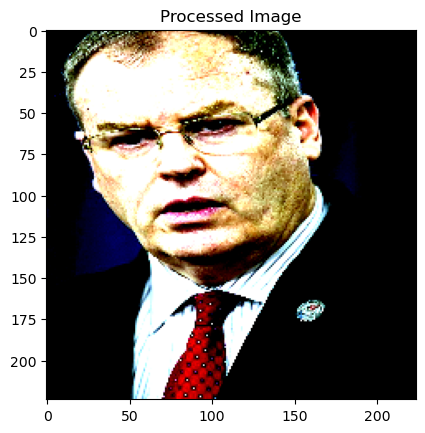

In [23]:
import matplotlib.pyplot as plt
import numpy as np

processed_img = image_preprocessing(gnd_sampled['image_path'][1])

processed_img_display = np.clip((processed_img * 255), 0, 255).astype(np.uint8)

rgb_img = cv2.cvtColor(processed_img_display, cv2.COLOR_BGR2RGB)

plt.imshow(rgb_img)
plt.title("Processed Image")
plt.show()


In [24]:
gnd_sampled.shape[0]

99386

In [25]:
gnd_sampled.columns

Index(['image_path', 'caption', 'article', 'headline', 'article_id',
       'image_index'],
      dtype='object')

In [26]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118


Looking in indexes: https://download.pytorch.org/whl/cu118


In [27]:
gnd_sampled_article = gnd_sampled_article = gnd_sampled.loc[:19999, ['article']]

In [28]:
from transformers import (
    BertTokenizer,
    BertForMaskedLM,
    BertConfig,
    LineByLineTextDataset,
    DataCollatorForLanguageModeling,
    Trainer,
    TrainingArguments
)

c:\Users\ritik\anaconda3\envs\datascience\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [29]:
!pip install torch

In [30]:
from datasets import Dataset

dataset = Dataset.from_pandas(gnd_sampled_article)

In [31]:


tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
max_seq_length = 512

def tokenize_function(examples,tokenizer):
    # Remove empty lines
    tokenized_inputs = tokenizer(
        examples["article"],
        truncation=True,
        max_length=max_seq_length,
        padding="max_length",
        return_tensors="pt"
    )

    # Create global attention mask: usually global attention on CLS token (token 0)
    global_attention_mask = []
    for input_ids in tokenized_inputs["input_ids"]:
        mask = [0] * len(input_ids)
        mask[0] = 1  # global attention on CLS token
        global_attention_mask.append(mask)

    tokenized_inputs["global_attention_mask"] = global_attention_mask
    return tokenized_inputs

dataset = dataset.map(
    tokenize_function,
    batched=True,
    remove_columns=["article"],
    fn_kwargs={"tokenizer": tokenizer},
    keep_in_memory=False,
    load_from_cache_file=False
)


Map: 100%|██████████| 20000/20000 [02:58<00:00, 112.18 examples/s]


In [32]:
!pip install transformers[torch]

In [33]:
!pip install transformers[torch]

In [34]:
tokenizer.vocab_size


30522

In [35]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"


In [36]:
import torch
torch.cuda.is_available()



False

In [37]:
dataset

Dataset({
    features: ['input_ids', 'token_type_ids', 'attention_mask', 'global_attention_mask'],
    num_rows: 20000
})

In [38]:
config = BertConfig(
    vocab_size=tokenizer.vocab_size,
    hidden_size=768, 
    num_hidden_layers=6, 
    num_attention_heads=8,
    max_position_embeddings=512
)
model = BertForMaskedLM(config)

print('No of parameters: ', model.num_parameters())



No of parameters:  66987066


In [39]:

data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer, mlm=True, mlm_probability=0.15
)



In [40]:
print(dataset.column_names)


['input_ids', 'token_type_ids', 'attention_mask', 'global_attention_mask']


In [41]:
# Defining training configuration\
training_args = TrainingArguments(
    output_dir='/EDA/',
    overwrite_output_dir=True,
    num_train_epochs=4,
    per_device_train_batch_size=5,
    fp16=False,
    save_steps=10_000,
    save_total_limit=2,
    no_cuda=True
)
model.to('cpu')  # ensure the model is on CPU

trainer = Trainer(
    model=model,
    args=training_args,
    data_collator=data_collator,
    train_dataset=dataset
)

# Perfrom pre-training and save the model
trainer.train()
trainer.save_model('/EDA/')

c:\Users\ritik\anaconda3\envs\datascience\Lib\site-packages\transformers\training_args.py:1577: FutureWarning: using `no_cuda` is deprecated and will be removed in version 5.0 of 🤗 Transformers. Use `use_cpu` instead
  warnings.warn(


Step,Training Loss
500,7.809700
1000,7.332100
1500,7.207500
2000,7.119100
2500,7.071500
3000,7.038900
3500,7.004800
4000,6.974300
4500,6.953100
5000,6.936400
